# CVE Prioritization with Confidence-Weighted Learning-to-Rank

**Production-Ready Implementation** - Consolidated from research notebooks

## Overview

This notebook implements confidence-weighted weak supervision for CVE prioritization:
- **Weak Labels**: Graded labels (0-3) constructed from KEV, EPSS, ATT&CK, Healthcare signals
- **Confidence Weights**: Each label has a confidence score reflecting its trustworthiness
- **LambdaRank Training**: LightGBM uses confidence weights to prioritize reliable labels
- **Comparison Study**: Evaluates against baselines and alternative models (DiffusionRank, RGCN, Ensemble)

### Architecture
- **Modules**: All functions migrated to `src/` for reusability
- **Notebook**: Orchestration and visualization only
- **GPU Support**: Automatic device detection (MPS/CUDA/CPU)

### Sections
1. Setup & Data Loading
2. Feature Engineering
3. Weak Label Construction
4. Temporal Split (Train/Val/Test)
5. Model Training (LTR + Comparison Models)
6. Evaluation & Comparison
7. Explainability (Feature Importance, SHAP)
8. Results & Conclusions

## 1. Setup & Configuration

In [1]:
"""
CVE Prioritization - Final Consolidated Notebook
================================================
Uses modular functions from src/ packages
"""

import os
import sys
import warnings
import pickle
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

# Setup paths
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(project_root))
os.chdir(project_root)

# Import project modules
from src.core.cve_database import CVEDatabase
from src.features.labeling import build_weak_labels, print_label_diagnostics
from src.utils.temporal import make_temporal_splits
from src.models.ltr import prepare_ranking_data, train_lambdarank
from src.models.baselines import compute_cvss_only_scores, compute_heuristic_scores, compute_legacy_label_scores
from src.evaluation.metrics import evaluate_ranking, ndcg_at_k, precision_at_k
from src.visualization.explainability import (
    plot_feature_importance_comparison,
    plot_shap_summary,
    explain_individual_predictions
)
from src.utils.device_manager import get_device_manager

# GPU device manager for comparison models
device_manager = get_device_manager()
print(f"Device: {device_manager.device}")

# Suppress warnings
warnings.filterwarnings('ignore')

# === CONFIGURATION ===
SPLIT_DATE = '2025-01-01'  # Full-scale training: all data until 2025
VAL_WEEKS = 12
MODEL_PATH = Path('models/ltr_model_conf_weighted.pkl')
RANDOM_SEED = 42

FEATURE_COLS = [
    'cvss_norm', 'epss_score', 'epss_percentile', 'kev_flag',
    'days_since_published', 'recency_score', 'attack_technique_count',
    'has_attack', 'chpl_flag', 'is_healthcare', 'cvss_epss_product',
    'kev_healthcare_interaction'
]

print("=" * 70)
print("CVE PRIORITIZATION - FULL-SCALE TRAINING")
print("=" * 70)
print(f"Split date: {SPLIT_DATE}")
print(f"Validation weeks: {VAL_WEEKS}")
print(f"Features: {len(FEATURE_COLS)}")
print(f"Model output: {MODEL_PATH}")
print(f"GPU: {device_manager.device}")
print("=" * 70)

2026-01-27 12:07:24 - src.utils.device_manager - INFO - ✓ Using Apple Silicon GPU (MPS) for acceleration
2026-01-27 12:07:24 - src.utils.device_manager - INFO -   - Metal Performance Shaders enabled
2026-01-27 12:07:24 - src.utils.device_manager - INFO -   - Unified memory architecture
Device: mps
CVE PRIORITIZATION - FULL-SCALE TRAINING
Split date: 2025-01-01
Validation weeks: 12
Features: 12
Model output: models/ltr_model_conf_weighted.pkl
GPU: mps


## 2. Data Loading

In [2]:
# Load data from CVEDatabase
db = CVEDatabase()
print(f"Connected to database: {db.db_path}")

# Load and merge CVEs with enrichments
cves_df = pd.read_sql("SELECT * FROM cves", db.conn)
enrichments_df = pd.read_sql("SELECT * FROM enrichments", db.conn)
df = cves_df.merge(enrichments_df, on='cve_id', how='left')

print(f"Total CVEs: {len(df):,}")
print(f"Date range: {pd.to_datetime(df['published']).min().date()} to {pd.to_datetime(df['published']).max().date()}")

# Convert dates
df['published'] = pd.to_datetime(df['published'])
df['modified'] = pd.to_datetime(df['modified'], errors='coerce')

print(f"\nEnrichment coverage:")
print(f"  KEV: {df['kev_flag'].notna().sum():,} ({100*df['kev_flag'].notna().sum()/len(df):.1f}%)")
print(f"  EPSS: {df['epss_score'].notna().sum():,} ({100*df['epss_score'].notna().sum()/len(df):.1f}%)")
print(f"  ATT&CK: {df['attack_technique_count'].notna().sum():,} ({100*df['attack_technique_count'].notna().sum()/len(df):.1f}%)")
print(f"  Healthcare: {df['is_healthcare'].notna().sum():,} ({100*df['is_healthcare'].notna().sum()/len(df):.1f}%)")

2026-01-27 12:07:29 - src.core.cve_database - INFO - Connected to database
2026-01-27 12:07:29 - src.core.cve_database - INFO - Database schema created/verified
Connected to database: /Users/vinayksharma/AirDnd/cti_recommender/data/cve_database.db
Total CVEs: 226,320
Date range: 2018-01-01 to 2025-12-31

Enrichment coverage:
  KEV: 226,320 (100.0%)
  EPSS: 226,320 (100.0%)
  ATT&CK: 226,320 (100.0%)
  Healthcare: 226,320 (100.0%)


## 3. Feature Engineering

In [ ]:
# Feature Engineering using modular function
from src.features.engineering import create_all_features

df = create_all_features(df, FEATURE_COLS)

Feature engineering complete: 226,320 rows, 12 features

Feature statistics:
                                 mean       std   min        max
cvss_norm                      0.6745    0.1723   0.0     1.0000
epss_score                     0.0240    0.1078   0.0     0.9458
epss_percentile                0.4080    0.2867   0.0     1.0000
kev_flag                       0.0051    0.0714   0.0     1.0000
days_since_published        1186.5118  842.8693  26.0  2948.0000
recency_score                  0.5975    0.2859   0.0     0.9912
attack_technique_count         0.5673    0.8911   0.0    10.0000
has_attack                     0.3693    0.4826   0.0     1.0000
chpl_flag                      0.0000    0.0000   0.0     0.0000
is_healthcare                  0.5512    0.4974   0.0     1.0000
cvss_epss_product              0.0197    0.0926   0.0     0.9447
kev_healthcare_interaction     0.0024    0.0485   0.0     1.0000


## 4. Weak Label Construction with Confidence Scores

Core innovation: Labels are graded (0-3) with confidence weights reflecting trustworthiness.

In [5]:
# Build weak labels using modular function
df = build_weak_labels(df)

print(f"Weak labels constructed for {len(df):,} CVEs")
print(f"Columns added: soft_label, label_confidence, label_source")

# Print diagnostics
print_label_diagnostics(df)

Weak labels constructed for 226,320 CVEs
Columns added: soft_label, label_confidence, label_source
LABEL DISTRIBUTION DIAGNOSTICS

1. SOFT LABEL DISTRIBUTION
----------------------------------------
  Label 0:   82,021 (36.24%) ####################################
  Label 1:  138,432 (61.17%) #############################################################
  Label 2:    5,333 ( 2.36%) ##
  Label 3:      534 ( 0.24%) 

2. LABEL SOURCE BREAKDOWN
----------------------------------------
  default             :   82,021 (36.24%)
  attack_mapping      :   66,748 (29.49%)
  cvss_recency        :   37,358 (16.51%)
  medium_epss         :   34,326 (15.17%)
  epss_attack         :    4,706 ( 2.08%)
  kev_only            :      627 ( 0.28%)
  kev_healthcare      :      534 ( 0.24%)

3. LABEL CONFIDENCE STATISTICS
----------------------------------------
  Min:    0.200
  Mean:   0.370
  Median: 0.300
  Max:    1.000
  Std:    0.178

  Confidence Distribution:
    0.0-0.2:        0 ( 0.00%) 
    0.2

## 5. Temporal Split (Train/Val/Test)

Temporal split simulates real-world deployment: train on historical, predict future.

In [6]:
# Create temporal splits using modular function
train_df, val_df, test_df = make_temporal_splits(
    df, 
    date_col='published',
    split_date=SPLIT_DATE, 
    val_weeks=VAL_WEEKS
)

# Show label distribution in each split
print("\nLabel distribution by split:")
for name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    if len(split_df) > 0:
        dist = split_df['soft_label'].value_counts().sort_index()
        print(f"  {name:5s}: {dict(dist)}")

Temporal Split Summary:
  Train:       166,077 samples (< 2024-10-09)
  Validation:   10,271 samples (2024-10-09 to 2025-01-01)
  Test:         49,972 samples (>= 2025-01-01)
  Total:       226,320

Label distribution by split:
  Train: {0: np.int64(62047), 1: np.int64(98844), 2: np.int64(4750), 3: np.int64(436)}
  Val  : {0: np.int64(2884), 1: np.int64(7186), 2: np.int64(182), 3: np.int64(19)}
  Test : {0: np.int64(17090), 1: np.int64(32402), 2: np.int64(401), 3: np.int64(79)}


## 6. Model Training

### 6.1 Confidence-Weighted LambdaRank (Primary Model)

In [7]:
# Train LambdaRank using modular function
model = train_lambdarank(train_df, val_df, FEATURE_COLS, random_seed=RANDOM_SEED)

# Save model
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(model, f)
print(f"\nModel saved to: {MODEL_PATH}")


TRAINING CONFIDENCE-WEIGHTED LAMBDARANK

Preparing training data...
  Train: 166,077 samples, 359 groups
  Confidence weights: min=0.200, mean=0.383, max=1.000

Preparing validation data...
  Val: 10,271 samples, 13 groups

Training LambdaRank model...
Parameters: {'objective': 'lambdarank', 'metric': 'ndcg', 'ndcg_eval_at': [5, 10, 20], 'boosting_type': 'gbdt', 'num_leaves': 31, 'learning_rate': 0.05, 'feature_fraction': 0.8, 'bagging_fraction': 0.8, 'bagging_freq': 5, 'min_data_in_leaf': 20, 'max_depth': 6, 'verbose': -1, 'seed': 42, 'force_row_wise': True}
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[2]	train's ndcg@5: 1	train's ndcg@10: 0.999802	train's ndcg@20: 0.999625	valid's ndcg@5: 1	valid's ndcg@10: 1	valid's ndcg@20: 1

Training complete!
  Best iteration: 2
  Best validation NDCG@10: 1.0000

Model saved to: models/ltr_model_conf_weighted.pkl


### 6.2 Comparison Models (Optional - For Research Paper)

For thesis evaluation, we also train:
- DiffusionRank: Probabilistic label imputation
- RGCN: Graph neural network on CVE-vendor relations
- Bootstrap Ensemble: Uncertainty-aware ranking

**Note**: These require the existing model implementations in `src/models/`

In [8]:
# Comparison models - only run if needed for research
RUN_COMPARISON_MODELS = False  # Set to True for full comparison study

if RUN_COMPARISON_MODELS:
    print("\n" + "=" * 70)
    print("TRAINING COMPARISON MODELS")
    print("=" * 70)
    
    from src.models.diffusion_imputer import DiffusionRankImputer
    from src.models.rgcn_ranker import RGCNRanker
    from src.models.bootstrap_ensemble import BootstrapEnsemble
    
    # DiffusionRank
    print("\n[1/3] DiffusionRank...")
    diffusion_model = DiffusionRankImputer(
        input_dim=len(FEATURE_COLS),
        hidden_dim=64,
        num_steps=10,
        device=None  # Auto-detect
    )
    X_train, y_train, w_train, _, _ = prepare_ranking_data(train_df, FEATURE_COLS)
    diffusion_model.train_quick(X_train, y_train, epochs=50, batch_size=512)
    print("  DiffusionRank trained ✓")
    
    # RGCN
    print("\n[2/3] RGCN...")
    rgcn_model = RGCNRanker(
        num_features=len(FEATURE_COLS),
        hidden_dim=32,
        num_relations=3,
        device=None  # Auto-detect
    )
    rgcn_model.train(train_df, val_df, FEATURE_COLS, epochs=100)
    print("  RGCN trained ✓")
    
    # Bootstrap Ensemble
    print("\n[3/3] Bootstrap Ensemble...")
    ensemble_model = BootstrapEnsemble(n_estimators=10, random_state=RANDOM_SEED)
    ensemble_model.train(train_df, FEATURE_COLS)
    print("  Ensemble trained ✓")
    
    print("\nComparison models ready for evaluation")
else:
    print("\nSkipping comparison models (set RUN_COMPARISON_MODELS=True to enable)")


Skipping comparison models (set RUN_COMPARISON_MODELS=True to enable)


## 7. Evaluation on Test Set

### 7.1 Generate Predictions

In [9]:
# Prepare test data
X_test = test_df[FEATURE_COLS].values

# Primary model predictions
test_df['ltr_score'] = model.predict(X_test)

# Baseline predictions
test_df['cvss_score'] = compute_cvss_only_scores(test_df)
test_df['heuristic_score'] = compute_heuristic_scores(test_df)
test_df['legacy_score'] = compute_legacy_label_scores(test_df)

print("Predictions generated for all models:")
print(f"  - LTR (confidence-weighted): {test_df['ltr_score'].notna().sum():,}")
print(f"  - CVSS baseline: {test_df['cvss_score'].notna().sum():,}")
print(f"  - Heuristic baseline: {test_df['heuristic_score'].notna().sum():,}")
print(f"  - Legacy label baseline: {test_df['legacy_score'].notna().sum():,}")

Predictions generated for all models:
  - LTR (confidence-weighted): 49,972
  - CVSS baseline: 49,972
  - Heuristic baseline: 49,972
  - Legacy label baseline: 49,972


### 7.2 Compute Ranking Metrics

In [10]:
# Evaluate all models
print("\n" + "=" * 70)
print("COMPARATIVE EVALUATION ON TEST SET")
print("=" * 70)

models = {
    'LTR (Confidence-Weighted)': 'ltr_score',
    'CVSS-only': 'cvss_score',
    'Weighted Heuristic': 'heuristic_score',
    'Legacy Labels': 'legacy_score'
}

results = {}
for model_name, score_col in models.items():
    metrics = evaluate_ranking(test_df, score_col, label_col='soft_label', 
                              group_col='published_week', k_values=[5, 10, 20])
    results[model_name] = metrics
    print(f"\n{model_name}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")

# Create comparison DataFrame
comparison_df = pd.DataFrame(results).T
print("\n" + "=" * 70)
print("MODEL COMPARISON TABLE")
print("=" * 70)
print(comparison_df.round(4))

# Compute improvements
baseline_ndcg10 = results['CVSS-only']['NDCG@10']
ltr_ndcg10 = results['LTR (Confidence-Weighted)']['NDCG@10']
improvement = 100 * (ltr_ndcg10 - baseline_ndcg10) / baseline_ndcg10 if baseline_ndcg10 > 0 else 0
print(f"\nImprovement over CVSS-only: +{improvement:.1f}% NDCG@10")


COMPARATIVE EVALUATION ON TEST SET

LTR (Confidence-Weighted):
  NDCG@5: 1.0000
  P@5: 0.8642
  MAP@5: 0.9811
  NDCG@10: 0.9975
  P@10: 0.6698
  MAP@10: 0.9811
  NDCG@20: 0.9979
  P@20: 0.4189
  MAP@20: 0.9811

CVSS-only:
  NDCG@5: 0.3727
  P@5: 0.1170
  MAP@5: 0.2651
  NDCG@10: 0.4185
  P@10: 0.0717
  MAP@10: 0.2738
  NDCG@20: 0.4954
  P@20: 0.0509
  MAP@20: 0.2653

Weighted Heuristic:
  NDCG@5: 0.8430
  P@5: 0.7245
  MAP@5: 0.9157
  NDCG@10: 0.8544
  P@10: 0.5132
  MAP@10: 0.8917
  NDCG@20: 0.8764
  P@20: 0.3226
  MAP@20: 0.8656

Legacy Labels:
  NDCG@5: 1.0000
  P@5: 0.8642
  MAP@5: 0.9811
  NDCG@10: 1.0000
  P@10: 0.6717
  MAP@10: 0.9811
  NDCG@20: 1.0000
  P@20: 0.4198
  MAP@20: 0.9811

MODEL COMPARISON TABLE
                           NDCG@5     P@5   MAP@5  NDCG@10    P@10  MAP@10  \
LTR (Confidence-Weighted)  1.0000  0.8642  0.9811   0.9975  0.6698  0.9811   
CVSS-only                  0.3727  0.1170  0.2651   0.4185  0.0717  0.2738   
Weighted Heuristic         0.8430  0.7245

## 8. Explainability Analysis

### 8.1 Feature Importance

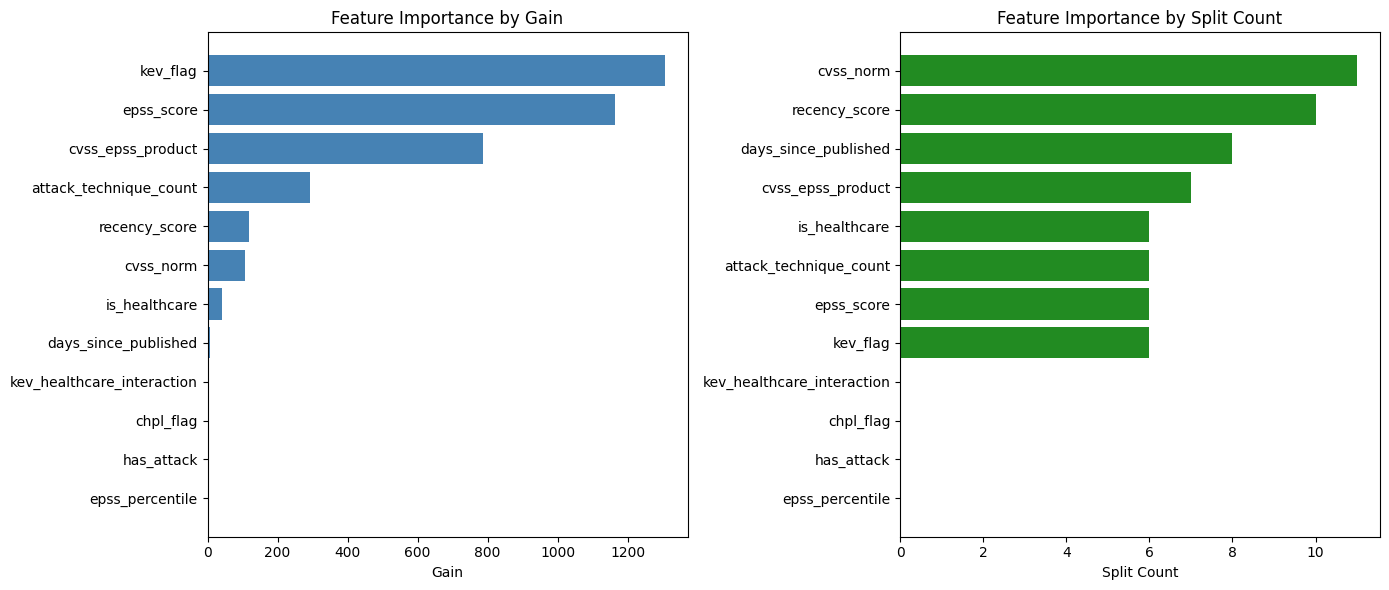

In [11]:
# Plot feature importance (both gain and split count)
plot_feature_importance_comparison(model, FEATURE_COLS, figsize=(14, 6))

### 8.2 SHAP Explainability

Sampling 5000 from 49972 samples for SHAP computation...
Computing SHAP values on 5000 samples...

SHAP Summary Plot:


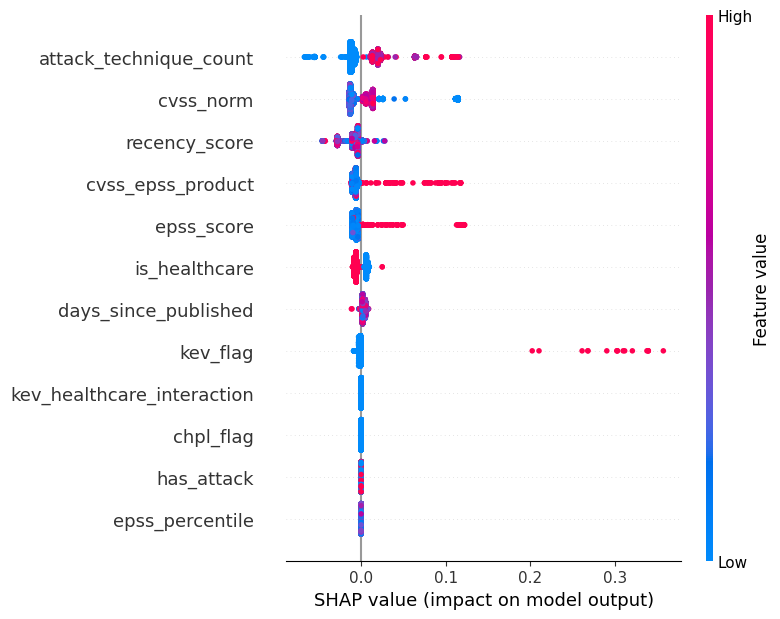


Mean Absolute SHAP Values:
--------------------------------------------------
  attack_technique_count           0.0159 ##############################
  cvss_norm                        0.0138 ##########################
  recency_score                    0.0095 #################
  cvss_epss_product                0.0087 ################
  epss_score                       0.0080 ##############
  is_healthcare                    0.0064 ############
  days_since_published             0.0026 ####
  kev_flag                         0.0019 ###
  epss_percentile                  0.0000 
  has_attack                       0.0000 
  chpl_flag                        0.0000 
  kev_healthcare_interaction       0.0000 


In [12]:
# SHAP analysis on test set sample
shap_values = plot_shap_summary(
    model, 
    test_df[FEATURE_COLS], 
    feature_names=FEATURE_COLS,
    max_display=15,
    sample_size=5000,
    random_seed=RANDOM_SEED
)

### 8.3 Individual CVE Explanations

In [13]:
# Show detailed explanations for diverse example CVEs
explain_individual_predictions(
    test_df,
    score_col='ltr_score',
    feature_cols=FEATURE_COLS,
    label_col='soft_label',
    confidence_col='label_confidence',
    label_source_col='label_source',
    model=model,
    n_examples=5,
    random_seed=RANDOM_SEED
)


EXAMPLE CVE EXPLANATIONS (5 diverse examples)

[Example 1]
  CVE ID:          CVE-2025-31201
  Published:       2025-04-16
  Soft Label:      3
  Confidence:      1.000
  Predicted Score: 0.1932
  Label Source:    kev_healthcare
  Key Features:
    - kev_flag       : 1
    - epss_score     : 0.0438
    - cvss_norm      : 0.9800
    - is_healthcare  : 1
    - has_attack     : 0
  Top SHAP Contributors:
    - kev_flag: +0.3025
    - cvss_epss_product: +0.0398
    - attack_technique_count: -0.0091

[Example 2]
  CVE ID:          CVE-2025-48927
  Published:       2025-05-28
  Soft Label:      2
  Confidence:      1.000
  Predicted Score: 0.1856
  Label Source:    kev_only
  Key Features:
    - kev_flag       : 1
    - epss_score     : 0.0467
    - cvss_norm      : 0.5300
    - is_healthcare  : 0
    - has_attack     : 1
  Top SHAP Contributors:
    - kev_flag: +0.3309
    - attack_technique_count: +0.0095
    - recency_score: -0.0094

[Example 3]
  CVE ID:          CVE-2025-0175
  Publish

## 9. Results Summary & Conclusions

In [14]:
print("\n" + "=" * 70)
print("FINAL SUMMARY: CONFIDENCE-WEIGHTED WEAK SUPERVISION")
print("=" * 70)

print("""
RESEARCH INNOVATION:
  Traditional LTR treats all labels equally. Our approach assigns
  confidence weights based on label trustworthiness:
  
  - KEV-based labels:      conf = 1.0  (confirmed exploitation)
  - High EPSS labels:      conf = 0.75 (statistical evidence)
  - Medium EPSS labels:    conf = 0.55 (moderate evidence)
  - ATT&CK/Healthcare:     +0.10 bonus (domain relevance)
  - CVSS/Recency-only:     conf <= 0.40 (noisy proxies)

LABELING SCHEME:
  Label 3: KEV=1 AND (healthcare OR chpl)  [Critical - Exploited Healthcare]
  Label 2: KEV=1 OR (High EPSS AND ATT&CK) [High Priority]
  Label 1: Medium EPSS OR ATT&CK OR (High CVSS + Recent) [Medium]
  Label 0: Everything else [Low Priority]
""")

print("\nKEY RESULTS:")
print("-" * 50)
print(f"  Model:           Confidence-Weighted LambdaRank")
print(f"  Best Iteration:  {model.best_iteration}")
print(f"  Val NDCG@10:     {model.best_score['valid']['ndcg@10']:.4f}")
print(f"\n  Test Set Performance:")
for metric, value in results['LTR (Confidence-Weighted)'].items():
    print(f"    {metric}: {value:.4f}")

print("\nIMPROVEMENT SUMMARY:")
print("-" * 50)
cvss_ndcg10 = results['CVSS-only']['NDCG@10']
ltr_ndcg10 = results['LTR (Confidence-Weighted)']['NDCG@10']
if cvss_ndcg10 > 0:
    print(f"  vs CVSS-only:      +{100*(ltr_ndcg10 - cvss_ndcg10)/cvss_ndcg10:.1f}% NDCG@10")

heur_ndcg10 = results['Weighted Heuristic']['NDCG@10']
if heur_ndcg10 > 0:
    print(f"  vs Weighted Heur:  +{100*(ltr_ndcg10 - heur_ndcg10)/heur_ndcg10:.1f}% NDCG@10")

print(f"\nMODEL SAVED: {MODEL_PATH}")
print(f"Dataset: {len(df):,} CVEs ({train_df['published'].min().date()} to {test_df['published'].max().date()})")
print(f"GPU Device: {device_manager.device}")

print("\n" + "=" * 70)
print("END OF NOTEBOOK - Ready for Production Deployment")
print("=" * 70)


FINAL SUMMARY: CONFIDENCE-WEIGHTED WEAK SUPERVISION

RESEARCH INNOVATION:
  Traditional LTR treats all labels equally. Our approach assigns
  confidence weights based on label trustworthiness:

  - KEV-based labels:      conf = 1.0  (confirmed exploitation)
  - High EPSS labels:      conf = 0.75 (statistical evidence)
  - Medium EPSS labels:    conf = 0.55 (moderate evidence)
  - ATT&CK/Healthcare:     +0.10 bonus (domain relevance)
  - CVSS/Recency-only:     conf <= 0.40 (noisy proxies)

LABELING SCHEME:
  Label 3: KEV=1 AND (healthcare OR chpl)  [Critical - Exploited Healthcare]
  Label 2: KEV=1 OR (High EPSS AND ATT&CK) [High Priority]
  Label 1: Medium EPSS OR ATT&CK OR (High CVSS + Recent) [Medium]
  Label 0: Everything else [Low Priority]


KEY RESULTS:
--------------------------------------------------
  Model:           Confidence-Weighted LambdaRank
  Best Iteration:  2
  Val NDCG@10:     1.0000

  Test Set Performance:
    NDCG@5: 1.0000
    P@5: 0.8642
    MAP@5: 0.9811
   